# Student Performance Analysis

## Project Overview

This project analyzes student performance data to identify patterns and factors associated with academic achievement.

The analysis focuses on mathematics, reading, and writing scores, as well as demographic and educational factors such as gender, parental education, lunch type, and test preparation course.

### Objectives

- Understand the characteristics of the dataset
- Perform data cleaning and preprocessing
- Analyze student score distributions
- Compare academic performance across different groups
- Examine relationships between subjects
- Identify key insights from the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance (1).csv


## 1. Data Understanding

The dataset contains information about student demographics, educational background, and examination scores.

The main variables include:

- Gender
- Race/Ethnicity
- Parental Level of Education
- Lunch
- Test Preparation Course
- Math Score
- Reading Score
- Writing Score

In [ ]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 2. Data Cleaning

Data cleaning was performed to ensure that the dataset was suitable for further analysis. The process included checking missing values, duplicate records, and standardizing column names.

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns = [
    "gender",
    "race_ethnicity",
    "parental_education",
    "lunch",
    "test_preparation",
    "math_score",
    "reading_score",
    "writing_score"
]
df.head()

,gender,race_ethnicity,parental_education,lunch,test_preparation,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Feature Engineering

A new variable called `average_score` was created by calculating the mean of mathematics, reading, and writing scores. This variable is used as an overall indicator of student academic performance.

In [ ]:
df["average_score"] = (
    df["math_score"] +
    df["reading_score"] +
    df["writing_score"]
) / 3
df.head()

,gender,race_ethnicity,parental_education,lunch,test_preparation,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [ ]:
df["average_score"].mean()

np.float64(67.77066666666666)

In [ ]:
print(
    f"Rata-rata nilai seluruh siswa: "
    f"{df['average_score'].mean():.2f}"
)

Rata-rata nilai seluruh siswa: 67.77


In [ ]:
total_students = len(df)

average_math = df["math_score"].mean()
average_reading = df["reading_score"].mean()
average_writing = df["writing_score"].mean()
overall_average = df["average_score"].mean()

print("Total Students:", total_students)
print(f"Average Math Score: {average_math:.2f}")
print(f"Average Reading Score: {average_reading:.2f}")
print(f"Average Writing Score: {average_writing:.2f}")
print(f"Overall Average Score: {overall_average:.2f}")

Total Students: 1000
Average Math Score: 66.09
Average Reading Score: 69.17
Average Writing Score: 68.05
Overall Average Score: 67.77


**Distribusi nilai**

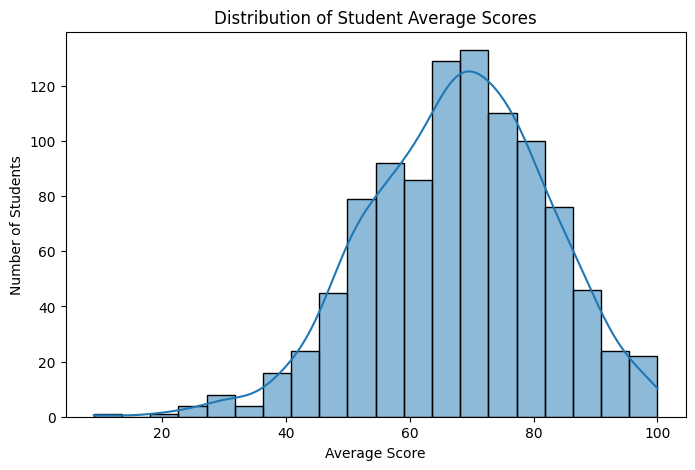

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="average_score",
    bins=20,
    kde=True
)

plt.title("Distribution of Student Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")

plt.show()

**Mata pelajaran mana yang memiliki rata-rata nilai tertinggi?**

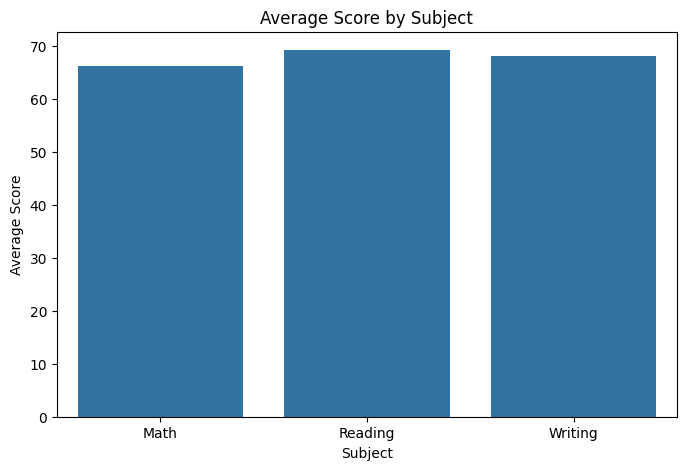

In [ ]:
subject_average = {
    "Math": df["math_score"].mean(),
    "Reading": df["reading_score"].mean(),
    "Writing": df["writing_score"].mean()
}

subject_average
plt.figure(figsize=(8,5))

sns.barplot(
    x=list(subject_average.keys()),
    y=list(subject_average.values())
)

plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")

plt.show()

**Apakah terdapat perbedaan rata-rata performa berdasarkan gender?**

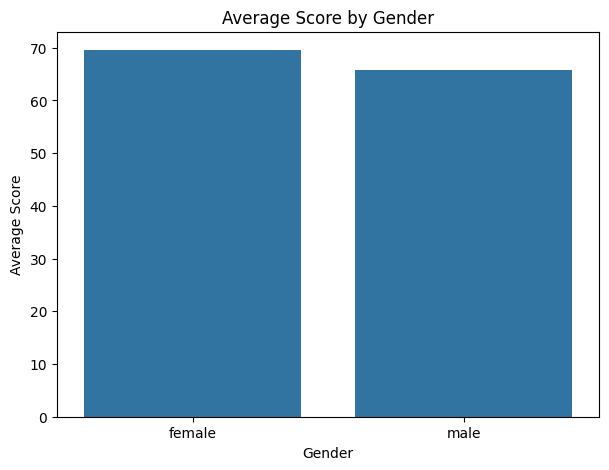

In [ ]:
gender_analysis = (
    df.groupby("gender")["average_score"]
    .mean()
)

gender_analysis
plt.figure(figsize=(7,5))

sns.barplot(
    x=gender_analysis.index,
    y=gender_analysis.values
)

plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")

plt.show()

**Apakah siswa yang mengikuti test preparation course memiliki performa lebih baik?**

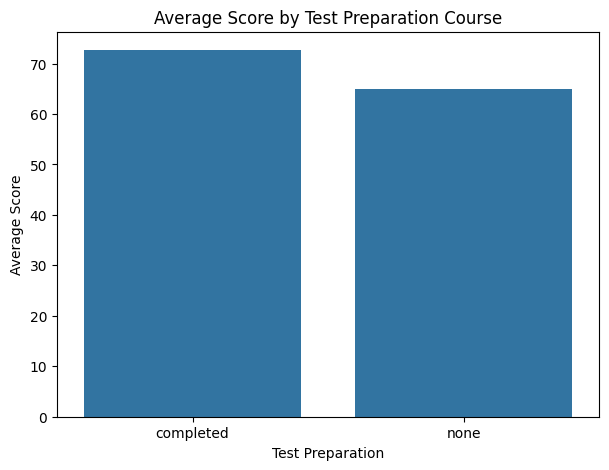

In [ ]:
test_prep_analysis = (
    df.groupby("test_preparation")["average_score"]
    .mean()
)

test_prep_analysis
plt.figure(figsize=(7,5))

sns.barplot(
    x=test_prep_analysis.index,
    y=test_prep_analysis.values
)

plt.title("Average Score by Test Preparation Course")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")

plt.show()

**Apakah tingkat pendidikan orang tua berkaitan dengan performa siswa?**

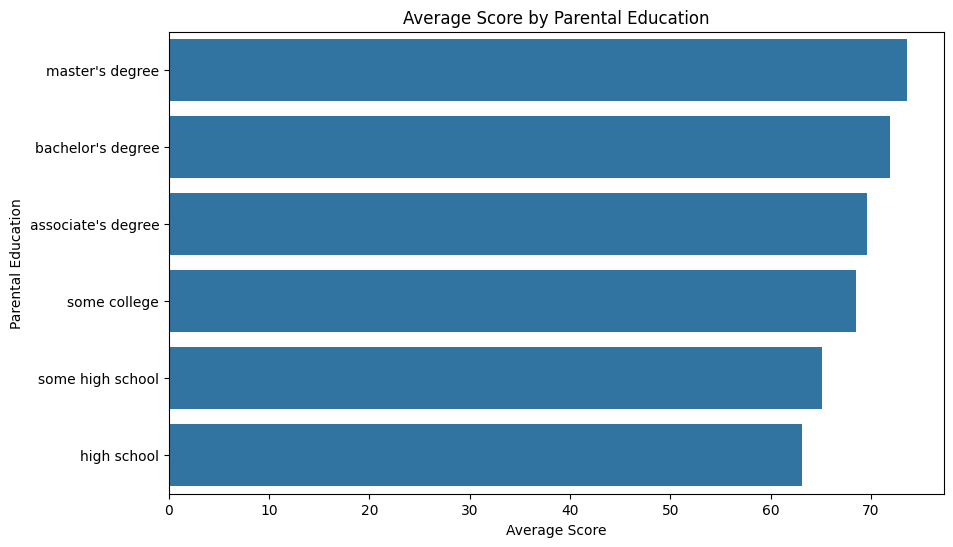

In [ ]:
parent_analysis = (
    df.groupby("parental_education")["average_score"]
    .mean()
    .sort_values(ascending=False)
)

parent_analysis
plt.figure(figsize=(10,6))

sns.barplot(
    x=parent_analysis.values,
    y=parent_analysis.index
)

plt.title("Average Score by Parental Education")
plt.xlabel("Average Score")
plt.ylabel("Parental Education")

plt.show()

**Analisis lunch**

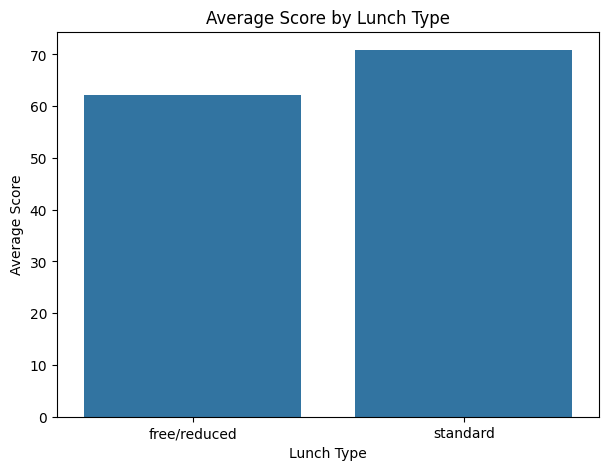

In [ ]:
lunch_analysis = (
    df.groupby("lunch")["average_score"]
    .mean()
)

lunch_analysis
plt.figure(figsize=(7,5))

sns.barplot(
    x=lunch_analysis.index,
    y=lunch_analysis.values
)

plt.title("Average Score by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")

plt.show()

**Analisis korelasi**

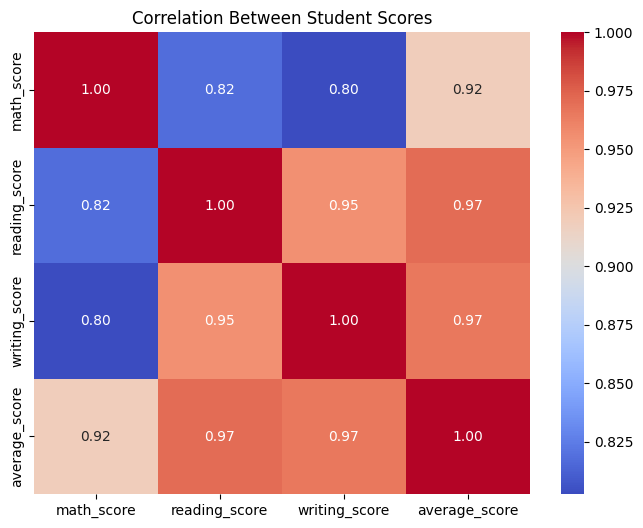

In [ ]:
correlation = df[
    [
        "math_score",
        "reading_score",
        "writing_score",
        "average_score"
    ]
].corr()

correlation
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Student Scores")

plt.show()

**Math vs Reading**

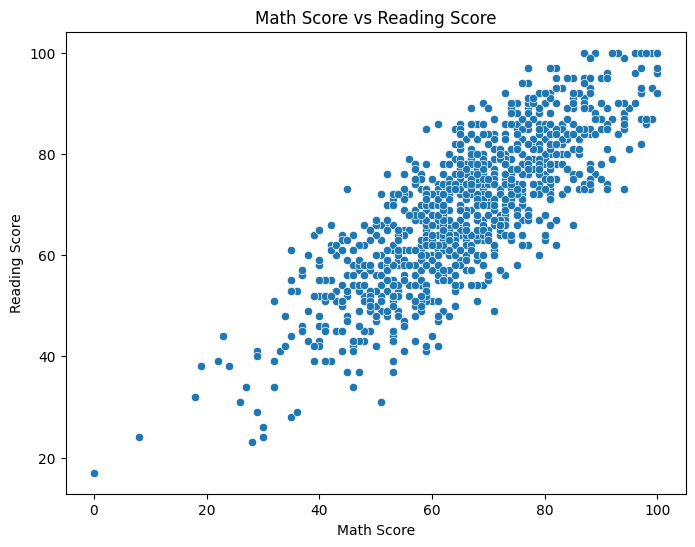

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="math_score",
    y="reading_score"
)

plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.show()

In [ ]:
def performance_category(score):
    if score >= 80:
        return "Excellent"
    elif score >= 70:
        return "Good"
    elif score >= 60:
        return "Average"
    else:
        return "Low"

In [ ]:
df["performance"] = df["average_score"].apply(
    performance_category
)

In [ ]:
df[["average_score", "performance"]].head()

,average_score,performance
0,72.666667,Good
1,82.333333,Excellent
2,92.666667,Excellent
3,49.333333,Low
4,76.333333,Good


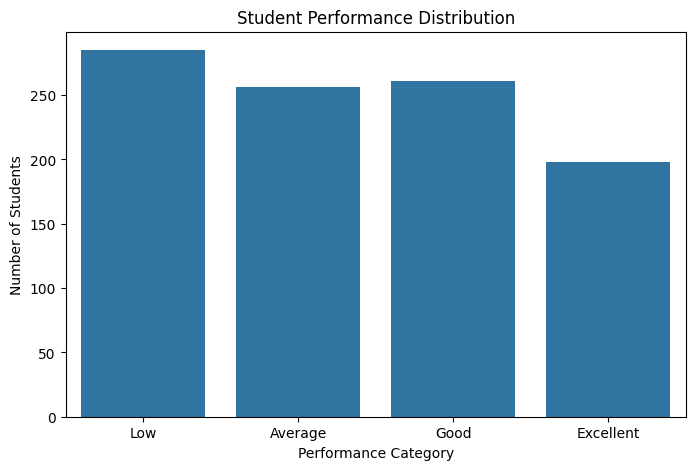

In [ ]:
df["performance"].value_counts()
plt.figure(figsize=(8,5))

order = ["Low", "Average", "Good", "Excellent"]

sns.countplot(
    data=df,
    x="performance",
    order=order
)

plt.title("Student Performance Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

## 5. Test Preparation Analysis

This analysis examines whether participation in the test preparation course is associated with differences in students' academic performance.

Average Score by Test Preparation:
test_preparation
completed    72.669460
none         65.038941
Name: average_score, dtype: float64


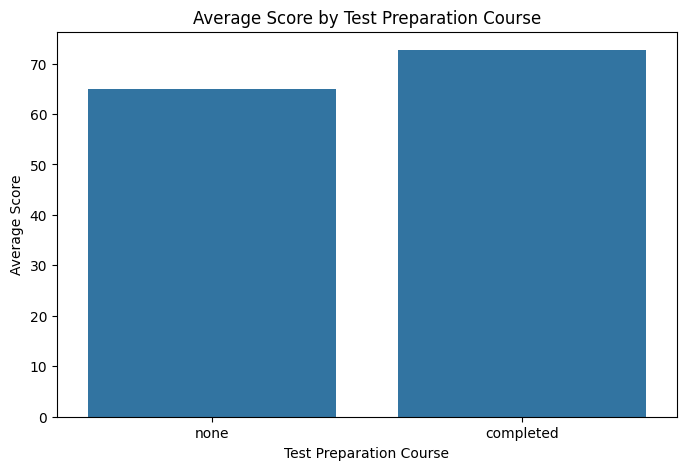

In [ ]:
test_prep_analysis = (
    df.groupby("test_preparation")["average_score"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Score by Test Preparation:")
print(test_prep_analysis)
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="test_preparation",
    y="average_score",
    errorbar=None
)

plt.title("Average Score by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")

plt.show()

Insight:

Students who completed the test preparation course had a higher average score of 72.67 compared with 65.04 for students who did not complete the course. The difference was 7.63 points.

In [ ]:
completed_score = df.loc[
    df["test_preparation"] == "completed",
    "average_score"
].mean()

none_score = df.loc[
    df["test_preparation"] == "none",
    "average_score"
].mean()

difference = completed_score - none_score

print(f"Average score - Completed: {completed_score:.2f}")
print(f"Average score - None: {none_score:.2f}")
print(f"Difference: {difference:.2f}")

Average score - Completed: 72.67
Average score - None: 65.04
Difference: 7.63


## 6. Gender Analysis

This analysis compares the academic performance of male and female students based on their average scores.

Average Score by Gender:
gender
female    69.569498
male      65.837483
Name: average_score, dtype: float64


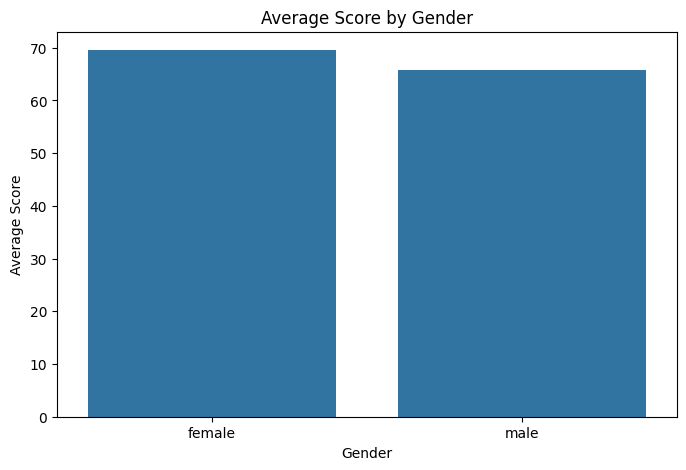

In [ ]:
gender_analysis = (
    df.groupby("gender")["average_score"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Score by Gender:")
print(gender_analysis)
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="gender",
    y="average_score",
    errorbar=None
)

plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")

plt.show()

Insight:

Female students had a higher average score of 69.57, compared with 65.84 for male students, resulting in a difference of approximately 3.73 points.

## 7. Parental Education Analysis

This analysis examines the relationship between parents' educational background and students' academic performance.

Average Score by Parental Education:
parental_education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64


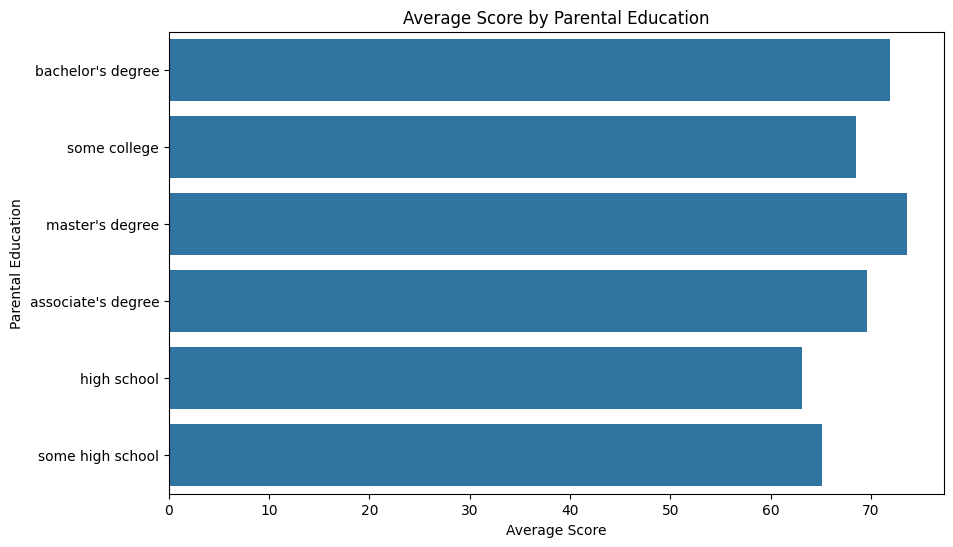

In [ ]:
parental_analysis = (
    df.groupby("parental_education")["average_score"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Score by Parental Education:")
print(parental_analysis)
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="average_score",
    y="parental_education",
    errorbar=None
)

plt.title("Average Score by Parental Education")
plt.xlabel("Average Score")
plt.ylabel("Parental Education")

plt.show()

## 8. Correlation Analysis

Correlation analysis is used to examine the relationships between students' mathematics, reading, and writing scores.

In [ ]:
score_columns = [
    "math_score",
    "reading_score",
    "writing_score"
]

correlation = df[score_columns].corr()

correlation

,math_score,reading_score,writing_score
math_score,1.000000,0.817580,0.802642
reading_score,0.817580,1.000000,0.954598
writing_score,0.802642,0.954598,1.000000


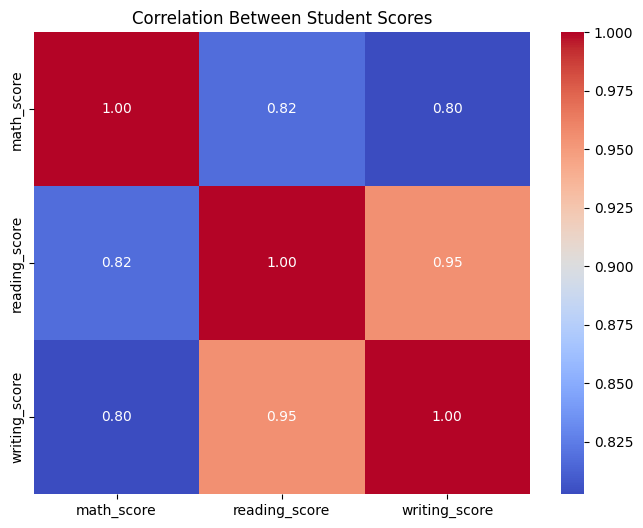

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Student Scores")

plt.show()

## 9. Key Findings

Based on the analysis, several key findings were identified:

1. Students who completed the test preparation course had a higher average score of 72.67 compared with 65.04 for students who did not complete the course.

2. Female students achieved a higher average score of 69.57 compared with 65.84 for male students.

3. Students whose parents had a master's degree achieved the highest average score of 73.60, while students whose parents had a high school education had the lowest average score of 63.10.

4. The mathematics, reading, and writing scores show positive relationships with each other, as indicated by the correlation analysis.

## 10. Conclusion

This analysis shows that students' academic performance varies across several characteristics. Students who completed the test preparation course achieved a higher average score than those who did not complete the course. Differences in average performance were also observed between male and female students and across parental education levels.

Overall, the analysis provides insights into patterns associated with student academic performance. However, the observed differences should not be interpreted as causal relationships because the analysis focuses on descriptive and correlation-based analysis.

In [ ]:
# Menyimpan dataset hasil cleaning dan feature engineering
df.to_csv("student_performance_cleaned.csv", index=False)

In [ ]:
from google.colab import files

files.download("student_performance_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>